# Comparação Ridge multialvo direto: TU versus TUO

Este notebook avalia se acrescentar **temperatura do ponto de orvalho** ao conjunto TU melhora a previsão direta de temperatura e umidade de `t+1` a `t+24`.

## Configurações

- **TU**: temperatura + umidade + atributos temporais.
- **TUO**: temperatura + umidade + ponto de orvalho + atributos temporais.

## Protocolo

- Treino: 2011–2023, excluindo 2022.
- Validação e seleção: 2024.
- Teste final: 2025.
- Avaliação adicional: 2026 parcial.
- Histórico: 24 horas.
- Saída direta: 24 horas × 2 alvos.
- Sem covariáveis meteorológicas futuras reais.
- TUO somente será preferido se melhorar a validação de forma consistente e sem prejuízo relevante a um dos alvos.

## 1. Importações e configuração

O notebook usa os artefatos das pastas `TU` e `TUO` gerados na preparação. Também pode importar as métricas do notebook anterior para conferir a reprodução de TU.

In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

DIRETORIO_DADOS = Path("dados_processados_multivariados")
DIRETORIO_RESULTADO_TU_ANTERIOR = Path("resultados_modelagem/linear_TU")
DIRETORIO_SAIDA = Path("resultados_modelagem/comparacao_ridge_TU_TUO")
DIRETORIO_SAIDA.mkdir(parents=True, exist_ok=True)

CONFIGURACOES = ["TU", "TUO"]
SPLITS = ["treino", "validacao", "teste", "avaliacao_2026"]
ALPHAS = [0.0, 0.01, 0.1, 1.0, 10.0, 100.0]
HORIZONTES_DESTAQUE = [1, 3, 6, 12, 24]
NOMES_ALVOS = ["temperatura_c", "umidade_pct"]
UNIDADES = {"temperatura_c": "°C", "umidade_pct": "p.p."}

print("IMPORTANTE")
print("- alpha é a intensidade da penalização Ridge e não possui unidade.")
print("- MAE/RMSE de temperatura serão mostrados em °C.")
print("- MAE/RMSE de umidade serão mostrados em pontos percentuais (p.p.).")
print("- os valores padronizados serão usados internamente e apenas no critério equilibrado de seleção.")

IMPORTANTE
- alpha é a intensidade da penalização Ridge e não possui unidade.
- MAE/RMSE de temperatura serão mostrados em °C.
- MAE/RMSE de umidade serão mostrados em pontos percentuais (p.p.).
- os valores padronizados serão usados internamente e apenas no critério equilibrado de seleção.


## 2. Carregamento dos artefatos

In [2]:
def carregar_configuracao(nome_configuracao):
    pasta = DIRETORIO_DADOS / nome_configuracao
    obrigatorios = [
        pasta / "treino.npz", pasta / "validacao.npz", pasta / "teste.npz",
        pasta / "avaliacao_2026.npz", pasta / "scaler_x.joblib",
        pasta / "scaler_y.joblib", pasta / "metadados.json",
    ]
    faltantes = [str(p) for p in obrigatorios if not p.exists()]
    if faltantes:
        raise FileNotFoundError("Arquivos ausentes:" + chr(10) + (chr(10)).join(faltantes))

    splits = {}
    for split in SPLITS:
        with np.load(pasta / f"{split}.npz") as arq:
            splits[split] = {chave: arq[chave] for chave in arq.files}

    with (pasta / "metadados.json").open("r", encoding="utf-8") as f:
        metadados = json.load(f)

    return {
        "splits": splits,
        "scaler_x": joblib.load(pasta / "scaler_x.joblib"),
        "scaler_y": joblib.load(pasta / "scaler_y.joblib"),
        "metadados": metadados,
    }

artefatos = {config: carregar_configuracao(config) for config in CONFIGURACOES}

for config in CONFIGURACOES:
    meta = artefatos[config]["metadados"]
    assert meta["configuracao"] == config
    assert meta["usa_covariaveis_meteorologicas_futuras"] is False
    print(config, meta["colunas_meteorologicas_historicas"], meta["contagens"])

TU ['temperatura_ar_horaria_c', 'umidade_horaria_pct'] {'treino': 84744, 'validacao': 7837, 'teste': 7970, 'avaliacao_2026': 4551}
TUO ['temperatura_ar_horaria_c', 'umidade_horaria_pct', 'temperatura_ponto_orvalho_c'] {'treino': 84744, 'validacao': 7837, 'teste': 7970, 'avaliacao_2026': 4551}


## 3. O que significa “achatar” as 24 horas

Os artefatos guardam o histórico como uma matriz por amostra:

```text
24 linhas (horas) × quantidade de atributos
```

A regressão Ridge espera uma linha por amostra. Por isso, a matriz é reorganizada em um vetor, sem misturar amostras e sem perder a ordem.

Exemplo simplificado com três horas e duas variáveis:

```text
Formato temporal:
              temperatura   umidade
hora t-3          20           80
hora t-2          21           76
hora t-1          22           72

Formato achatado:
[20, 80, 21, 76, 22, 72]
```

No conjunto TU real, o histórico possui 24 × 6 = 144 números. Os quatro atributos temporais futuros acrescentam 24 × 4 = 96 números. Assim, cada amostra TU vira uma linha com 240 atributos. TUO possui um canal histórico adicional e resulta em 264 atributos.

O achatamento não calcula média e não elimina horas. Ele apenas muda a organização dos mesmos valores para o formato aceito por um modelo tabular.

In [3]:
def preparar_X(split):
    hist = split["X_historico"].reshape(len(split["X_historico"]), -1)
    futuro = split["X_futuro_temporal"].reshape(len(split["X_futuro_temporal"]), -1)
    return np.concatenate([hist, futuro], axis=1).astype(np.float32, copy=False)


def preparar_y(split):
    return split["y"].reshape(len(split["y"]), -1).astype(np.float32, copy=False)

matrizes = {}
for config in CONFIGURACOES:
    matrizes[config] = {
        "X": {s: preparar_X(artefatos[config]["splits"][s]) for s in SPLITS},
        "y": {s: preparar_y(artefatos[config]["splits"][s]) for s in SPLITS},
    }
    print(
        f"{config}: X_historico original = {artefatos[config]['splits']['treino']['X_historico'].shape}; "
        f"X achatado + futuro temporal = {matrizes[config]['X']['treino'].shape}; "
        f"y direto = {matrizes[config]['y']['treino'].shape}"
    )

TU: X_historico original = (84744, 24, 6); X achatado + futuro temporal = (84744, 240); y direto = (84744, 48)
TUO: X_historico original = (84744, 24, 7); X achatado + futuro temporal = (84744, 264); y direto = (84744, 48)


## 4. Funções de métricas e conversão para unidades reais

O modelo é treinado com valores padronizados, mas as métricas apresentadas ao usuário são calculadas depois da transformação inversa.

In [4]:
def remodelar_y(y):
    return y.reshape(-1, 24, 2)


def inverter_y(y_norm, scaler_y):
    forma = y_norm.shape
    return scaler_y.inverse_transform(y_norm.reshape(-1, 2)).reshape(forma)


def metricas_por_horizonte(y_real, y_pred, config, split, alpha):
    linhas=[]
    for h in range(24):
        for j, alvo in enumerate(NOMES_ALVOS):
            real, pred = y_real[:,h,j], y_pred[:,h,j]
            linhas.append({
                "configuracao":config, "split":split, "alpha":alpha,
                "horizonte_horas":h+1, "alvo":alvo, "unidade":UNIDADES[alvo],
                "mae":mean_absolute_error(real,pred),
                "rmse":mean_squared_error(real,pred)**0.5,
                "vies":float(np.mean(pred-real)), "n":len(real),
            })
    return pd.DataFrame(linhas)


def metricas_globais(y_real, y_pred, config, split, alpha):
    linhas=[]
    for j, alvo in enumerate(NOMES_ALVOS):
        real, pred=y_real[:,:,j].ravel(), y_pred[:,:,j].ravel()
        linhas.append({
            "configuracao":config, "split":split, "alpha":alpha, "alvo":alvo,
            "unidade":UNIDADES[alvo],
            "mae":mean_absolute_error(real,pred),
            "rmse":mean_squared_error(real,pred)**0.5,
            "vies":float(np.mean(pred-real)), "n_previsoes":len(real),
        })
    return pd.DataFrame(linhas)


def criterio_equilibrado(y_real, y_pred, scaler_y):
    mae_temp=mean_absolute_error(y_real[:,:,0].ravel(),y_pred[:,:,0].ravel())
    mae_umid=mean_absolute_error(y_real[:,:,1].ravel(),y_pred[:,:,1].ravel())
    pad_temp=mae_temp/scaler_y.scale_[0]
    pad_umid=mae_umid/scaler_y.scale_[1]
    return (pad_temp+pad_umid)/2, pad_temp, pad_umid, mae_temp, mae_umid

## 5. Treinamento visível e seleção de `alpha`

Cada configuração treina seis modelos. Agora o notebook mostra o início, o fim, o tempo, o erro de treino e o erro de validação. Os erros em unidades reais são exibidos ao lado do critério padronizado.

In [5]:
resultados_selecao=[]
modelos={}

for config in CONFIGURACOES:
    print(chr(10) + "="*70)
    print(f"CONFIGURAÇÃO {config}")
    print("="*70)
    X=matrizes[config]["X"]
    y=matrizes[config]["y"]
    scaler_y=artefatos[config]["scaler_y"]
    y_treino_orig=inverter_y(remodelar_y(y["treino"]),scaler_y)
    y_val_orig=inverter_y(remodelar_y(y["validacao"]),scaler_y)

    for pos,alpha in enumerate(ALPHAS,1):
        print(f"[{pos}/{len(ALPHAS)}] Treinando {config} com alpha={alpha}...")
        inicio=time.perf_counter()
        modelo=Ridge(alpha=alpha,fit_intercept=True,solver="lsqr",tol=1e-4)
        modelo.fit(X["treino"],y["treino"])
        tempo=time.perf_counter()-inicio

        pred_treino=inverter_y(remodelar_y(modelo.predict(X["treino"])),scaler_y)
        pred_val=inverter_y(remodelar_y(modelo.predict(X["validacao"])),scaler_y)
        crit_val,pad_temp,pad_umid,mae_temp_val,mae_umid_val=criterio_equilibrado(y_val_orig,pred_val,scaler_y)
        _,_,_,mae_temp_tr,mae_umid_tr=criterio_equilibrado(y_treino_orig,pred_treino,scaler_y)

        resultados_selecao.append({
            "configuracao":config,"alpha":alpha,"tempo_treino_segundos":tempo,
            "mae_treino_temperatura_c":mae_temp_tr,
            "mae_validacao_temperatura_c":mae_temp_val,
            "mae_treino_umidade_pct":mae_umid_tr,
            "mae_validacao_umidade_pct":mae_umid_val,
            "mae_validacao_padronizado_temperatura":pad_temp,
            "mae_validacao_padronizado_umidade":pad_umid,
            "criterio_validacao_padronizado_medio":crit_val,
        })
        modelos[(config,alpha)]=modelo
        print(
            f"    concluído em {tempo:.1f}s | "
            f"treino: {mae_temp_tr:.3f} °C, {mae_umid_tr:.3f} p.p. | "
            f"validação: {mae_temp_val:.3f} °C, {mae_umid_val:.3f} p.p. | "
            f"critério equilibrado={crit_val:.6f}"
        )

resultados_selecao=pd.DataFrame(resultados_selecao)
melhores=(resultados_selecao.sort_values(["configuracao","criterio_validacao_padronizado_medio","alpha"])
          .groupby("configuracao",as_index=False).first())
print(chr(10)+"Melhores configurações por validação de 2024:")
display(melhores)


CONFIGURAÇÃO TU
[1/6] Treinando TU com alpha=0.0...
    concluído em 31.8s | treino: 1.537 °C, 7.448 p.p. | validação: 1.697 °C, 8.259 p.p. | critério equilibrado=0.378761
[2/6] Treinando TU com alpha=0.01...
    concluído em 31.7s | treino: 1.537 °C, 7.448 p.p. | validação: 1.697 °C, 8.259 p.p. | critério equilibrado=0.378761
[3/6] Treinando TU com alpha=0.1...
    concluído em 32.3s | treino: 1.536 °C, 7.448 p.p. | validação: 1.697 °C, 8.259 p.p. | critério equilibrado=0.378760
[4/6] Treinando TU com alpha=1.0...
    concluído em 31.1s | treino: 1.536 °C, 7.448 p.p. | validação: 1.697 °C, 8.259 p.p. | critério equilibrado=0.378751
[5/6] Treinando TU com alpha=10.0...
    concluído em 28.4s | treino: 1.538 °C, 7.448 p.p. | validação: 1.698 °C, 8.259 p.p. | critério equilibrado=0.378908
[6/6] Treinando TU com alpha=100.0...
    concluído em 22.2s | treino: 1.541 °C, 7.449 p.p. | validação: 1.702 °C, 8.261 p.p. | critério equilibrado=0.379321

CONFIGURAÇÃO TUO
[1/6] Treinando TUO com a

,configuracao,alpha,tempo_treino_segundos,mae_treino_temperatura_c,mae_validacao_temperatura_c,mae_treino_umidade_pct,mae_validacao_umidade_pct,mae_validacao_padronizado_temperatura,mae_validacao_padronizado_umidade,criterio_validacao_padronizado_medio
0,TU,1.0,31.134647,1.536332,1.696510,7.447912,8.258918,0.341426,0.416077,0.378751
1,TUO,0.1,26.983481,1.527011,1.683895,7.397505,8.140503,0.338887,0.410111,0.374499


## 6. Avaliação dos melhores modelos

In [6]:
metricas_h=[]
metricas_g=[]
previsoes={}

for _,linha in melhores.iterrows():
    config=linha["configuracao"]
    alpha=float(linha["alpha"])
    modelo=modelos[(config,alpha)]
    scaler_y=artefatos[config]["scaler_y"]
    previsoes[config]={}

    for split in ["treino","validacao","teste","avaliacao_2026"]:
        y_real=inverter_y(remodelar_y(matrizes[config]["y"][split]),scaler_y)
        y_pred=inverter_y(remodelar_y(modelo.predict(matrizes[config]["X"][split])),scaler_y)
        metricas_h.append(metricas_por_horizonte(y_real,y_pred,config,split,alpha))
        metricas_g.append(metricas_globais(y_real,y_pred,config,split,alpha))
        if split != "treino":
            previsoes[config][split]={"y_real":y_real.astype(np.float32),"y_pred":y_pred.astype(np.float32)}

metricas_h=pd.concat(metricas_h,ignore_index=True)
metricas_g=pd.concat(metricas_g,ignore_index=True)

display(metricas_g.sort_values(["split","alvo","configuracao"]).reset_index(drop=True))

,configuracao,split,alpha,alvo,unidade,mae,rmse,vies,n_previsoes
0,TU,avaliacao_2026,1.0,temperatura_c,°C,1.514856,2.131869,3.678679e-02,109224
1,TUO,avaliacao_2026,0.1,temperatura_c,°C,1.509436,2.120637,4.710776e-02,109224
2,TU,avaliacao_2026,1.0,umidade_pct,p.p.,7.307822,10.253129,-1.140046e+00,109224
3,TUO,avaliacao_2026,0.1,umidade_pct,p.p.,7.308827,10.249426,-1.239488e+00,109224
4,TU,teste,1.0,temperatura_c,°C,1.700491,2.401878,3.839809e-02,191280
5,TUO,teste,0.1,temperatura_c,°C,1.689248,2.395614,4.156461e-02,191280
6,TU,teste,1.0,umidade_pct,p.p.,8.251848,11.632867,-5.367724e-01,191280
7,TUO,teste,0.1,umidade_pct,p.p.,8.222882,11.613235,-5.695474e-01,191280
8,TU,treino,1.0,temperatura_c,°C,1.536332,2.163805,-7.259916e-07,2033856
9,TUO,treino,0.1,temperatura_c,°C,1.527011,2.152049,-1.532649e-06,2033856


## 7. Comparação TU versus TUO

A diferença percentual é calculada como ganho de TUO sobre TU. Valor positivo indica redução do erro ao acrescentar ponto de orvalho.

In [7]:
def comparar_configuracoes(metricas):
    tu=metricas[metricas.configuracao=="TU"].set_index(["split","alvo"])
    tuo=metricas[metricas.configuracao=="TUO"].set_index(["split","alvo"])
    linhas=[]
    for idx in tu.index:
        split,alvo=idx
        linhas.append({
            "split":split,"alvo":alvo,"unidade":tu.loc[idx,"unidade"],
            "mae_TU":tu.loc[idx,"mae"],"mae_TUO":tuo.loc[idx,"mae"],
            "ganho_mae_TUO_pct":100*(tu.loc[idx,"mae"]-tuo.loc[idx,"mae"])/tu.loc[idx,"mae"],
            "rmse_TU":tu.loc[idx,"rmse"],"rmse_TUO":tuo.loc[idx,"rmse"],
            "ganho_rmse_TUO_pct":100*(tu.loc[idx,"rmse"]-tuo.loc[idx,"rmse"])/tu.loc[idx,"rmse"],
        })
    return pd.DataFrame(linhas)

comparacao=comparar_configuracoes(metricas_g)
display(comparacao.sort_values(["split","alvo"]).reset_index(drop=True))

,split,alvo,unidade,mae_TU,mae_TUO,ganho_mae_TUO_pct,rmse_TU,rmse_TUO,ganho_rmse_TUO_pct
0,avaliacao_2026,temperatura_c,°C,1.514856,1.509436,0.357756,2.131869,2.120637,0.526853
1,avaliacao_2026,umidade_pct,p.p.,7.307822,7.308827,-0.013761,10.253129,10.249426,0.036119
2,teste,temperatura_c,°C,1.700491,1.689248,0.661161,2.401878,2.395614,0.260818
3,teste,umidade_pct,p.p.,8.251848,8.222882,0.351024,11.632867,11.613235,0.168760
4,treino,temperatura_c,°C,1.536332,1.527011,0.606718,2.163805,2.152049,0.543294
5,treino,umidade_pct,p.p.,7.447912,7.397505,0.676793,10.406962,10.347040,0.575791
6,validacao,temperatura_c,°C,1.696510,1.683895,0.743562,2.324284,2.310486,0.593632
7,validacao,umidade_pct,p.p.,8.258918,8.140503,1.433782,11.389413,11.243221,1.283583


## 8. Gráficos do erro por horizonte

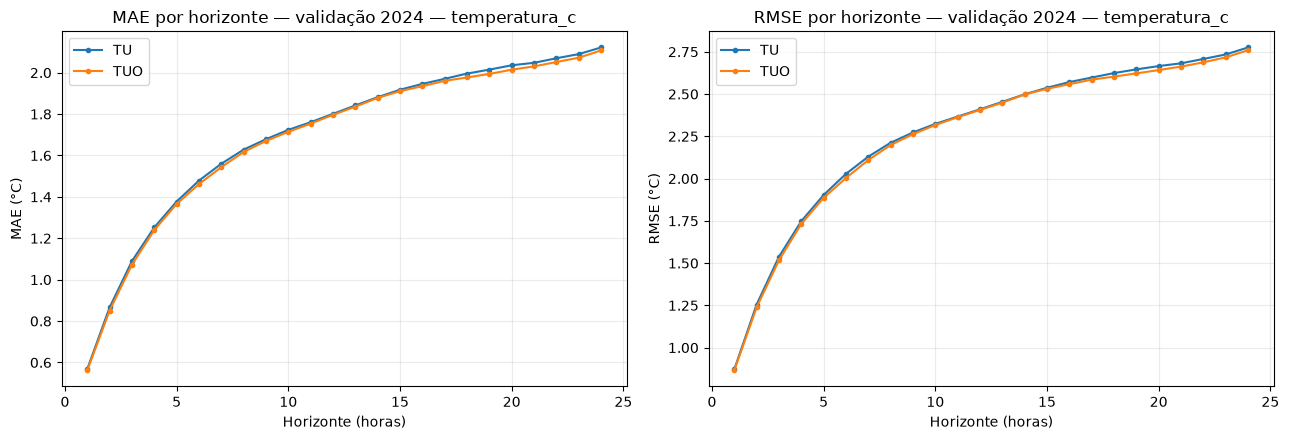

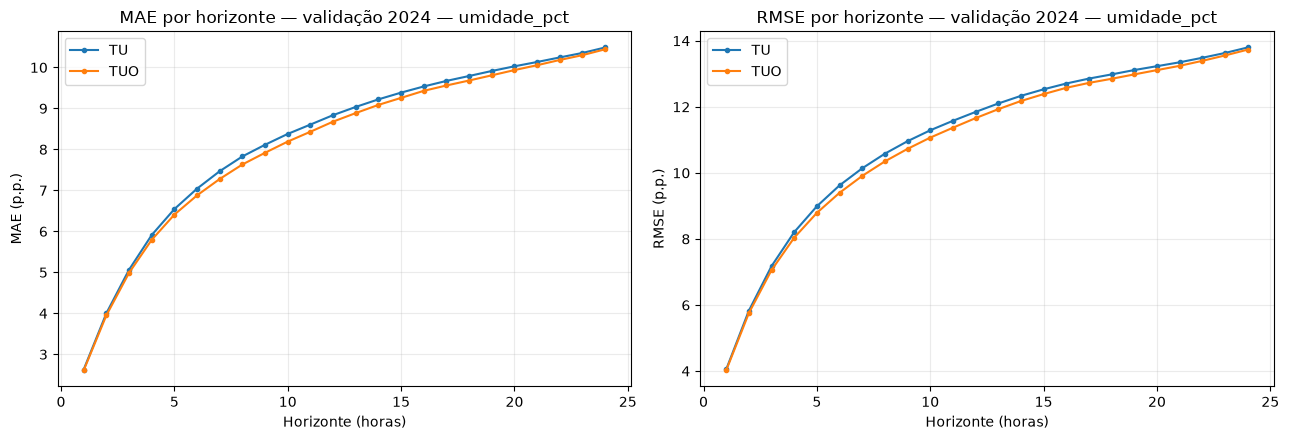

In [8]:
for alvo in NOMES_ALVOS:
    fig,axes=plt.subplots(1,2,figsize=(13,4.5))
    for config in CONFIGURACOES:
        recorte=metricas_h[(metricas_h.split=="validacao")&(metricas_h.alvo==alvo)&(metricas_h.configuracao==config)]
        axes[0].plot(recorte.horizonte_horas,recorte.mae,marker="o",markersize=3,label=config)
        axes[1].plot(recorte.horizonte_horas,recorte.rmse,marker="o",markersize=3,label=config)
    axes[0].set(title=f"MAE por horizonte — validação 2024 — {alvo}",xlabel="Horizonte (horas)",ylabel=f"MAE ({UNIDADES[alvo]})")
    axes[1].set(title=f"RMSE por horizonte — validação 2024 — {alvo}",xlabel="Horizonte (horas)",ylabel=f"RMSE ({UNIDADES[alvo]})")
    for ax in axes:
        ax.legend(); ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 9. Exemplo de uma previsão de 24 horas

O exemplo usa a primeira origem do teste de 2025 e exibe valores reais e previstos em unidades originais.

In [9]:
config_exemplo="TUO"
split_exemplo="teste"
idx=0
inicio=pd.to_datetime(artefatos[config_exemplo]["splits"][split_exemplo]["inicio_previsao"][idx],utc=True)
horas=pd.date_range(inicio,periods=24,freq="h")
y_real=previsoes[config_exemplo][split_exemplo]["y_real"][idx]
y_pred=previsoes[config_exemplo][split_exemplo]["y_pred"][idx]

exemplo=pd.DataFrame({
    "datetime_utc":horas,
    "temperatura_real_c":y_real[:,0],
    "temperatura_prevista_c":y_pred[:,0],
    "erro_abs_temperatura_c":np.abs(y_pred[:,0]-y_real[:,0]),
    "umidade_real_pct":y_real[:,1],
    "umidade_prevista_pct":y_pred[:,1],
    "erro_abs_umidade_pp":np.abs(y_pred[:,1]-y_real[:,1]),
})
display(exemplo.round(2))

C:\Users\adilson.pas\AppData\Local\Temp\ipykernel_34264\704228537.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(exemplo.round(2))


,datetime_utc,temperatura_real_c,temperatura_prevista_c,erro_abs_temperatura_c,umidade_real_pct,umidade_prevista_pct,erro_abs_umidade_pp
0,2025-01-02 00:00:00+00:00,24.299999,24.750000,0.45,72.0,70.970001,1.03
1,2025-01-02 01:00:00+00:00,23.799999,24.260000,0.46,73.0,72.940002,0.06
2,2025-01-02 02:00:00+00:00,23.100000,23.900000,0.80,79.0,74.250000,4.75
3,2025-01-02 03:00:00+00:00,22.600000,23.620001,1.02,81.0,75.790001,5.21
4,2025-01-02 04:00:00+00:00,22.500000,23.100000,0.60,82.0,78.059998,3.94
5,2025-01-02 05:00:00+00:00,22.600000,22.280001,0.32,81.0,81.160004,0.16
6,2025-01-02 06:00:00+00:00,22.400000,21.690001,0.71,82.0,83.750000,1.75
7,2025-01-02 07:00:00+00:00,21.299999,21.290001,0.01,87.0,85.699997,1.30
8,2025-01-02 08:00:00+00:00,21.900000,21.440001,0.46,82.0,85.910004,3.91
9,2025-01-02 09:00:00+00:00,21.500000,21.790001,0.29,84.0,84.150002,0.15


## 10. Regra explícita de decisão

TUO será recomendado somente se, na validação de 2024:

1. reduzir o critério padronizado médio;
2. não piorar o MAE de temperatura em mais de 1%;
3. não piorar o MAE de umidade em mais de 1%.

O teste de 2025 será relatado, mas não decidirá a seleção.

In [10]:
val=comparacao[comparacao.split=="validacao"].set_index("alvo")
melhor_crit={r.configuracao:r.criterio_validacao_padronizado_medio for _,r in melhores.iterrows()}
criterio_melhora=melhor_crit["TUO"] < melhor_crit["TU"]
temp_ok=val.loc["temperatura_c","ganho_mae_TUO_pct"] >= -1.0
umid_ok=val.loc["umidade_pct","ganho_mae_TUO_pct"] >= -1.0
RECOMENDACAO="TUO" if criterio_melhora and temp_ok and umid_ok else "TU"

print("Critério TU:",melhor_crit["TU"])
print("Critério TUO:",melhor_crit["TUO"])
print("Temperatura dentro da tolerância:",temp_ok)
print("Umidade dentro da tolerância:",umid_ok)
print("CONFIGURAÇÃO RECOMENDADA PELA VALIDAÇÃO:",RECOMENDACAO)

Critério TU: 0.378751400061876
Critério TUO: 0.3744992255748054
Temperatura dentro da tolerância: True
Umidade dentro da tolerância: True
CONFIGURAÇÃO RECOMENDADA PELA VALIDAÇÃO: TUO


## 11. Salvamento e verificação final

In [11]:
resultados_selecao.to_csv(DIRETORIO_SAIDA/"selecao_alpha_TU_TUO.csv",index=False,encoding="utf-8-sig")
melhores.to_csv(DIRETORIO_SAIDA/"melhores_por_configuracao.csv",index=False,encoding="utf-8-sig")
metricas_h.to_csv(DIRETORIO_SAIDA/"metricas_por_horizonte_TU_TUO.csv",index=False,encoding="utf-8-sig")
metricas_g.to_csv(DIRETORIO_SAIDA/"metricas_globais_TU_TUO.csv",index=False,encoding="utf-8-sig")
comparacao.to_csv(DIRETORIO_SAIDA/"comparacao_TU_TUO.csv",index=False,encoding="utf-8-sig")
exemplo.to_csv(DIRETORIO_SAIDA/"exemplo_previsao_24h_TUO.csv",index=False,encoding="utf-8-sig")

for _,linha in melhores.iterrows():
    config=linha["configuracao"]; alpha=float(linha["alpha"])
    joblib.dump(modelos[(config,alpha)],DIRETORIO_SAIDA/f"modelo_ridge_{config}.joblib")

meta_saida={
    "modelo":"Ridge multialvo direto","configuracoes":["TU","TUO"],
    "recomendacao_validacao_2024":RECOMENDACAO,
    "regra_decisao":{"criterio_equilibrado_deve_melhorar":True,"tolerancia_piora_por_alvo_pct":1.0},
    "usa_covariaveis_meteorologicas_futuras":False,
    "unidades_metricas":{"temperatura":"°C","umidade":"pontos percentuais"},
    "alphas_selecionados":{r.configuracao:float(r.alpha) for _,r in melhores.iterrows()},
    "versoes":{"python":sys.version.split()[0],"numpy":np.__version__,"pandas":pd.__version__,"plataforma":platform.platform()},
}
with (DIRETORIO_SAIDA/"metadados_comparacao.json").open("w",encoding="utf-8") as f:
    json.dump(meta_saida,f,ensure_ascii=False,indent=2)

obrigatorios=["selecao_alpha_TU_TUO.csv","melhores_por_configuracao.csv","metricas_por_horizonte_TU_TUO.csv","metricas_globais_TU_TUO.csv","comparacao_TU_TUO.csv","exemplo_previsao_24h_TUO.csv","modelo_ridge_TU.joblib","modelo_ridge_TUO.joblib","metadados_comparacao.json"]
assert all((DIRETORIO_SAIDA/n).exists() for n in obrigatorios)
assert np.isfinite(metricas_g[["mae","rmse","vies"]].to_numpy()).all()
assert meta_saida["usa_covariaveis_meteorologicas_futuras"] is False
print("VERIFICAÇÃO FINAL: OK")
print("Recomendação pela validação de 2024:",RECOMENDACAO)

VERIFICAÇÃO FINAL: OK
Recomendação pela validação de 2024: TUO


## Encerramento

Após a revisão, a próxima decisão será uma destas:

- manter TU por simplicidade;
- adotar TUO porque o ponto de orvalho acrescentou ganho consistente;
- se houver tempo, testar TUOV apenas como ablação adicional;
- avançar com a configuração selecionada para `HistGradientBoostingRegressor`.